* Task 2 — Build Time Series Forecasting Models (Tesla Stock)*

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Time series modeling
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


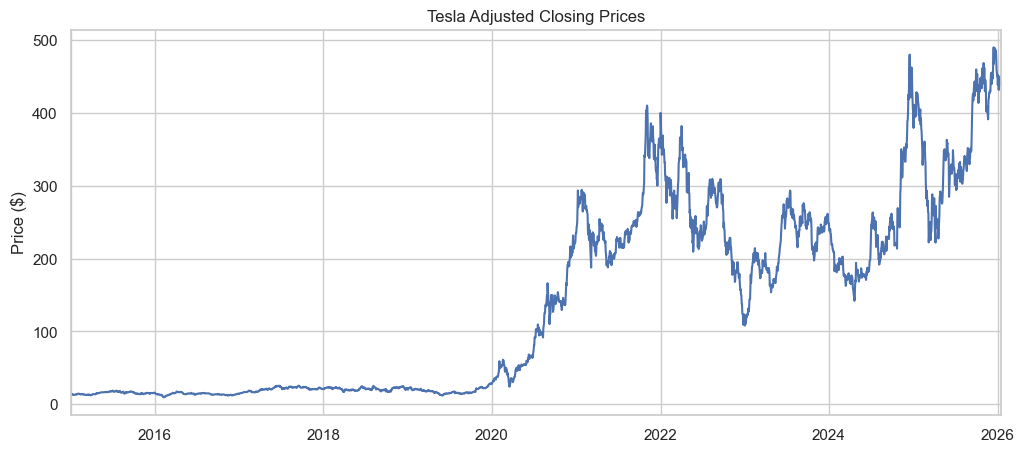

In [2]:
# Paths
project_root = r"C:\Users\JERUSALEM\Desktop\portfolio-optimization"
data_folder = os.path.join(project_root, "data")
figures_folder = os.path.join(project_root, "reports", "figures")

# Load aligned Tesla prices
tsla_prices = pd.read_csv(os.path.join(data_folder, "prices_aligned.csv"), index_col=0, parse_dates=True)["TSLA"]

# Plot price series
tsla_prices.plot(title="Tesla Adjusted Closing Prices")
plt.ylabel("Price ($)")
plt.savefig(os.path.join(figures_folder, "tsla_prices.png"), dpi=300)
plt.show()


In [3]:
train = tsla_prices["2015-01-01":"2024-12-31"]
test = tsla_prices["2025-01-01":]

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (2608,)
Test shape: (272,)


In [4]:
import pmdarima as pm

arima_model = pm.auto_arima(
    train,
    seasonal=False,     # Start with ARIMA, set seasonal=True for SARIMA
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print(arima_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16858.977, Time=4.65 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.34 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.22 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=16878.233, Time=1.56 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16878.294, Time=2.26 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16857.881, Time=2.83 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16878.243, Time=1.83 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=16859.736, Time=5.73 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=16862.636, Time=5.06 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=16857.948, Time=3.90 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16874.277, Time=1.83 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=16858.879, Time=6.29 sec
 ARIMA(3,1,2)(0,0,0

c:\Users\JERUSALEM\Desktop\portfolio-optimization\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\JERUSALEM\Desktop\portfolio-optimization\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\JERUSALEM\Desktop\portfolio-optimization\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


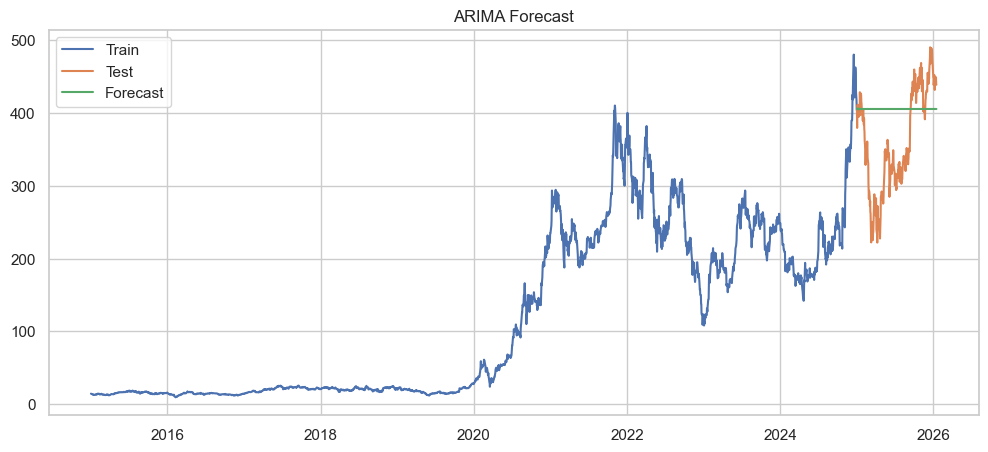

In [5]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=arima_model.order)
fitted = model.fit()

# Forecast for test period
forecast = fitted.forecast(steps=len(test))
forecast.index = test.index

# Plot results
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(forecast, label="Forecast")
plt.title("ARIMA Forecast")
plt.legend()
plt.savefig(os.path.join(figures_folder, "arima_forecast.png"), dpi=300)
plt.show()


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"ARIMA Metrics → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")


ARIMA Metrics → MAE: 69.30, RMSE: 83.10, MAPE: 22.48%


In [7]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
test_scaled = scaler.transform(test.values.reshape(-1,1))


In [8]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(np.concatenate([train_scaled[-seq_length:], test_scaled]), seq_length)


In [10]:
from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape=(seq_length, 1)))  # Use Input layer first
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


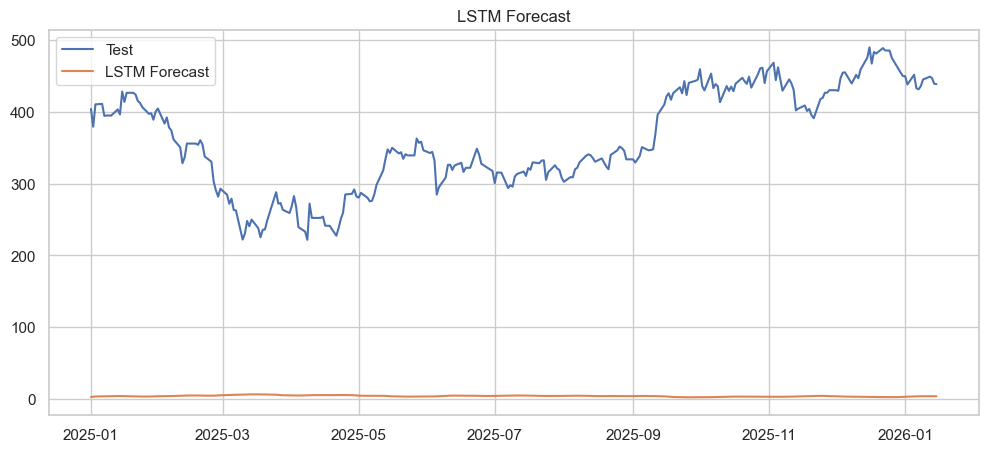

In [11]:
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)

# Plot LSTM forecast
plt.plot(test.index, test.values, label="Test")
plt.plot(test.index, pred, label="LSTM Forecast")
plt.title("LSTM Forecast")
plt.legend()
plt.savefig(os.path.join(figures_folder, "lstm_forecast.png"), dpi=300)
plt.show()


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lstm = mean_absolute_error(test.values, pred)
rmse_lstm = np.sqrt(mean_squared_error(test.values, pred))
mape_lstm = np.mean(np.abs((test.values - pred) / test.values)) * 100
print(f"LSTM MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.2f}%")


LSTM MAE: 356.55, RMSE: 363.56, MAPE: 98.76%


In [13]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [mae, mae_lstm],
    "RMSE": [rmse, rmse_lstm],
    "MAPE": [mape, mape_lstm]
})

print(comparison)


   Model         MAE        RMSE       MAPE
0  ARIMA   69.300690   83.095089  22.480771
1   LSTM  356.551328  363.557364  98.764426


In [14]:
pd.DataFrame(forecast, index=test.index, columns=["ARIMA_Forecast"]).to_csv(os.path.join(data_folder, "arima_forecast.csv"))
pd.DataFrame(pred, index=test.index, columns=["LSTM_Forecast"]).to_csv(os.path.join(data_folder, "lstm_forecast.csv"))
